In [26]:
import numpy as np
from src.tracking.track import Track
from src.tracking.track_manager import TrackManager
from src.tracking.kalman_filter import KalmanFilter
import time
import matplotlib.pyplot as plt
from src.evaluation import metrics, plotting
from src.scenarios import truth_generator
from src.models import measurement_models, motion_models
from configs.multi_track_ss_baseline import R, Q, P0, truth_data, id_miss_index, dt,Q

In [27]:
def angle_between(v1, v2):
    v1_u = v1 / np.linalg.norm(v1)
    v2_u = v2 / np.linalg.norm(v2)
    dot_product = np.dot(v1_u, v2_u)
    angle_rad = np.arccos(np.clip(dot_product, -1.0, 1.0))
    
    return np.degrees(angle_rad)

In [28]:
truth_states, truth_positions, truth_velocities, truth_times, truth_exists, scans = truth_generator.generate_truth(100, truth_data, P0, id_miss_index, R, dt)


In [29]:
# places all of the k-1 tracks into kf objects and track objects. 
trax = [
    Track(
        track['id'],
        KalmanFilter(F=motion_models.F, H=measurement_models.H, R=R, Q=Q, x_hat_km1_km1=track["x"], P_km1_km1=track["P"])
    )
    for track in truth_data
]
tracker = TrackManager(trax, 5.991) # all tracks are stored into the trackmanager
# truth_states - For each track id x_i_t = [p_x, p_y, v_x, v_y] for i = {1,2,3,4,5} and t = {k-1, k, k+1, ... k+99}
# truth_positions - For each track id x_i_t = [p_x, p_y] for i = {1,2,3,4,5} and t = {k-1, k, k+1, ... k+99}
# truth_velocities - For each track id x_i_t = [v_x, v_y] for i = {1,2,3,4,5} and t = {k-1, k, k+1, ... k+99}
# truth_times - delta = 1.5, t = {delta*i, delta*i+1,...} for i = {0,1, 2, ... 100} 
# truth_exists - truth_exists = {1 if track_i should have a hit at t = k, 0 otherwise}
# scans - {z_1, z_2, z_3, ...} for z_i in F@x + v(0, R) for timestep k_j , j = {k, k+1, ...}
tracker.scan_log[0] = {"time": truth_times[0], "num_measurements": 0, 
                        "num_tracks": len(tracker.tracks)}

for index, measurements in scans.items():
    tracker.scan_log[index] = {"time": truth_times[index], 
                                "num_measurements": len(measurements), 
                                "num_tracks": len(tracker.tracks)}
    tracker.predict_all()
    assignments, unassigned_tracks, unassigned_measurements, _ = \
        tracker.gnn_associate(measurements, index)

    assignment_map = {a['track_id']: a['measurement'] for a in assignments}
    unassigned_track_ids = {t['track_id'] for t in unassigned_tracks}
    tracks_to_delete = []

    tracker.pred_log[index] = {}
    for trk in tracker.tracks:
        tracker.pred_log[index][trk.track_id] = [trk.kf.x_hat_k_km1, trk.kf.P_k_km1]
        
        if trk.track_id in assignment_map: 
            z_k = assignment_map[trk.track_id] # Get measurement from ass map

            trk.update(z_k) # use measurement / prediction to update 

            if trk.tentative: # if its a tentative track increase hit count by 1
                trk.hit_count += 1
                if trk.hit_count >= 2: # promote track if hit count >= 2
                    trk.promote_track()
                    print(f"tentative Track ID: {trk.track_id} Promoted! Hit Count: {trk.hit_count}")
            print(f"Track {trk.track_id} Detected!")

        elif trk.track_id in unassigned_track_ids: # if this track id is unassigned then mark as a miss and coast
                                                    # predication from k|k-1 -> k|k
            trk.miss()
            trk.coast()
            print(f"Track {trk.track_id} Missed Detection!")

        if trk.tentative and trk.missed_count >= 2: # delete a tentative track with missed count >= 2
            print(f"tentative Track ID: {trk.track_id} Deleted, Missed Count: {trk.missed_count} >= 2")
            tracks_to_delete.append(trk)

        elif (not trk.tentative) and trk.missed_count >= 3:
            # delete a confirmed track with miss count > = 3
            print(f"Confirmed Track ID: {trk.track_id} Deleted, Missed Count: {trk.missed_count} >= 3")
            tracks_to_delete.append(trk)

    for trk in tracks_to_delete: # accutally delete the tracks from the list.
        tracker.delete_track(trk)

    for meas in unassigned_measurements:
        # For each unassigned measurement create a tentative track
        ten_track_id = tracker.tentative_track(meas['measurement'], tracker.get_new_track_id(), motion_models.F, measurement_models.H, Q, R)
        print(f"tentative Track ID: {ten_track_id} Created!")



Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Detected!
Track 4 Detected!
Track 5 Detected!
Track 1 Detected!
Track 2 Detected!
Track 3 Missed Detection!
Track 4 Detected!
Track 5 Detected!
tentative Track ID: 6 Created!
Track 1 Missed Detection!
Track 2 Detected!
Track 3 Missed Detection!
Track 4 Detected!
Track 5 Detected!
tentative Track ID: 6 Promoted! Hit Count: 2


In [30]:
rmse, _, n = metrics.position_rmse_from_truth_and_predlog(truth_states, tracker.pred_log)
per_track_rmse = metrics.position_rmse_per_track_from_truth_and_predlog(truth_states, tracker.pred_log)
coverage = metrics.track_coverage_from_truth_and_predlog(truth_states, tracker.pred_log)
print("Total Tracks:", max([x.track_id for x in tracker.tracks]))
print("Overall RMSE:", rmse)
print("Per-track RMSE:", per_track_rmse)
print("Coverage:", coverage)
print("Matched samples:", n, "of", int(n/coverage))

Total Tracks: 19
Overall RMSE: 7.527886021014257
Per-track RMSE: {1: 6.57005987842294, 2: 7.906851170265616, 3: 9.644881196061888, 4: 6.1975017391899945, 5: 9.624917303634863}
Coverage: 0.38
Matched samples: 190 of 500


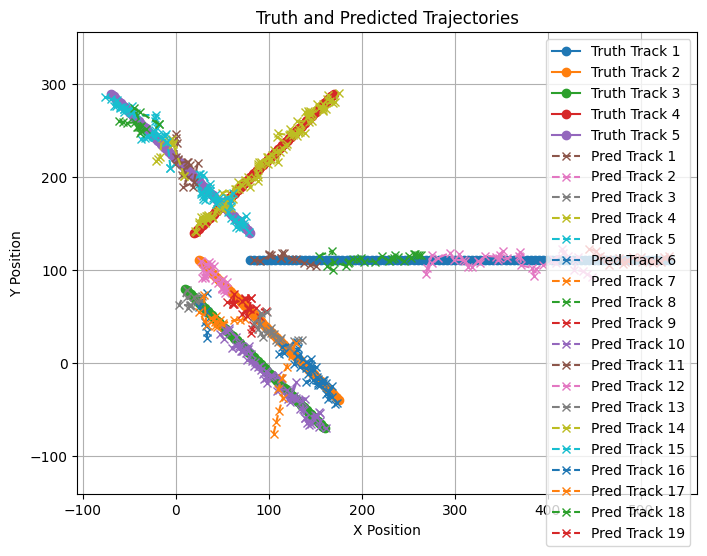

In [31]:
plotting.plot_tracks(truth_positions, tracker)